# **Model Training Via Data Set**

--- Model Evaluation & Saving ---

Saved: Linear_Regression_model.joblib
  Linear_Regression -> R2: 0.8762, RMSE: 0.1941

Saved: Decision_Tree_model.joblib
  Decision_Tree -> R2: 0.9809, RMSE: 0.0762

Saved: Random_Forest_Tuned_model.joblib
  Random_Forest_Tuned -> R2: 0.9871, RMSE: 0.0626

Saved: XGBoost_model.joblib
  XGBoost -> R2: 0.9885, RMSE: 0.0592



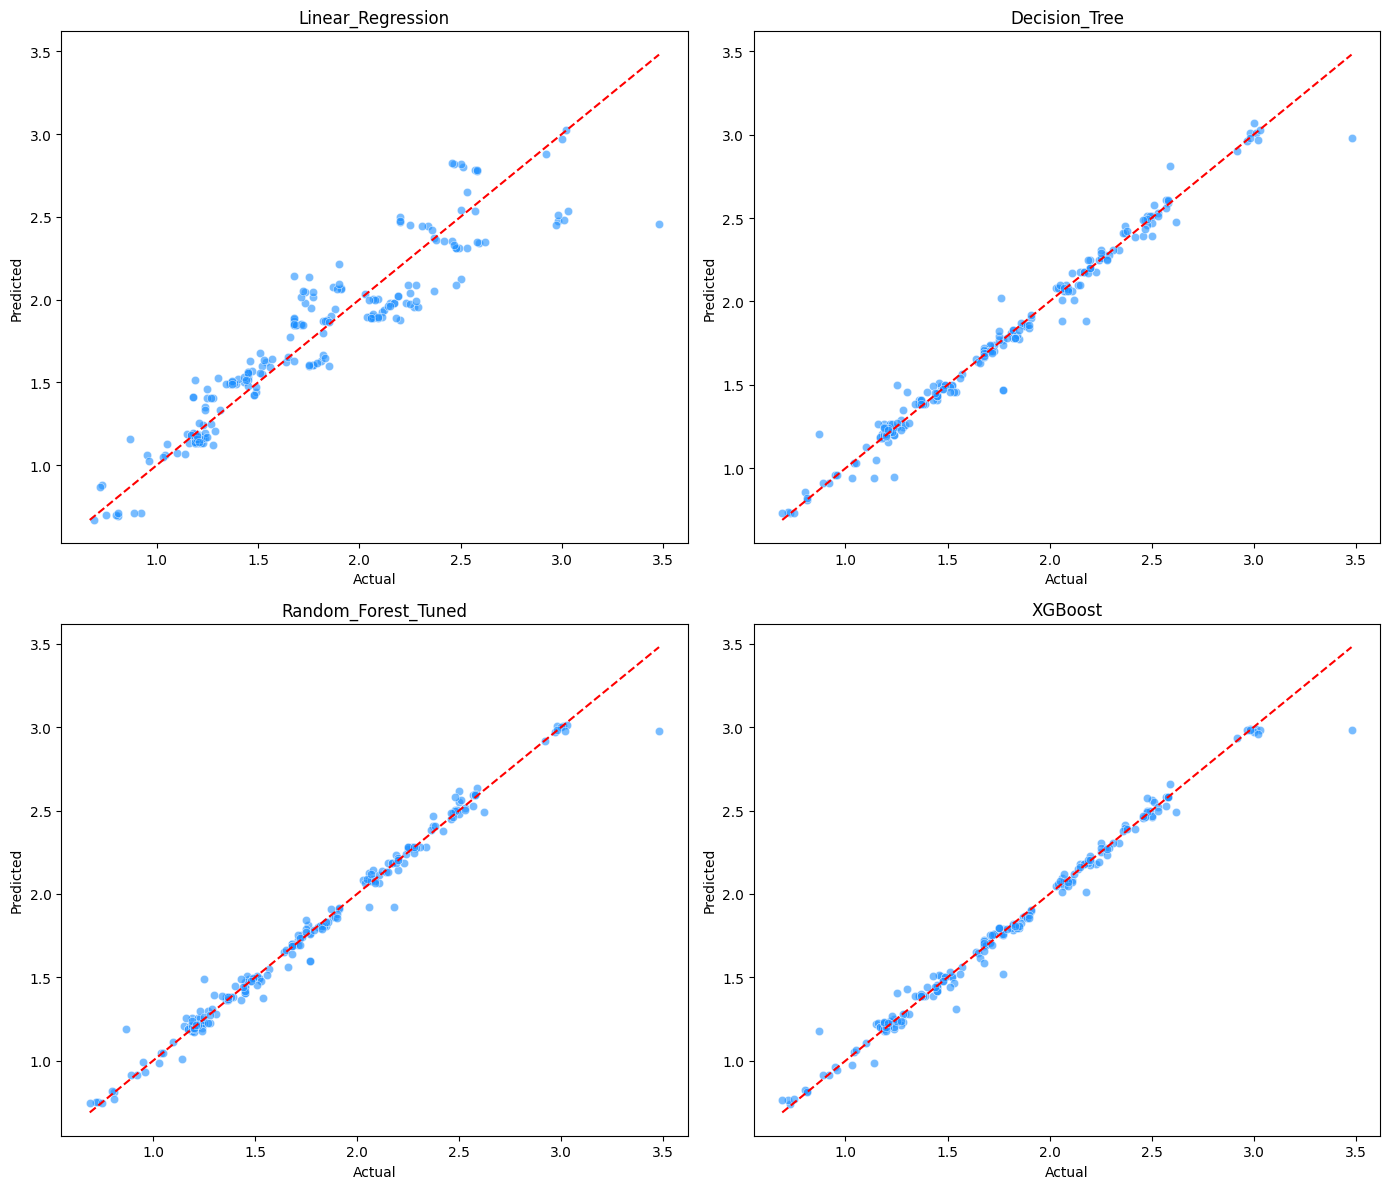

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import joblib

# 1. Load the dataset
try:
    df = pd.read_csv("/content/Final Data Set.csv")
except FileNotFoundError:
    print("Error: Please upload '/content/Final_Data_Set.csv' to your Colab environment.")
    raise

# 2. Preprocessing
df = df.dropna(subset=['FactorOfSafety'])
df = df.fillna(df.mean(numeric_only=True))

X = df.drop(columns=['FactorOfSafety'])
y = df['FactorOfSafety']
X = pd.get_dummies(X, drop_first=True)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Hyperparameter Tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# 5. Initialize Models
models = {
    "Linear_Regression": LinearRegression(),
    "Decision_Tree": DecisionTreeRegressor(random_state=42),
    "Random_Forest_Tuned": best_rf,
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100, learning_rate=0.05)
}

# 6. Setup Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# 7. Train, Evaluate, Plot, and SAVE models
print("--- Model Evaluation & Saving ---\n")

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Save the model to a file
    filename = f"{name}_model.joblib"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"  {name} -> R2: {r2:.4f}, RMSE: {rmse:.4f}\n")

    ax = axes[i]
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.6, color='dodgerblue')
    min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    ax.set_title(f"{name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

# 8. Show and Save

plt.tight_layout()
plt.show()

### Streamlit app code

# **Installing Streamlit For Web Application**

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 90.3 MB/s eta 0:00:00


# **Code For The Streamlit Website**

In [ ]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import os

# --- 1. MODEL LOADING ---
@st.cache_resource
def load_model():
    # Tries to load locally first.
    # Make sure your new saved model (e.g., 'Random_Forest_Tuned_model.joblib') is in the same folder.
    model_path = 'Random_Forest_Tuned_model.joblib'

    # Fallback for Colab absolute path
    if not os.path.exists(model_path):
        model_path = '/content/Random_Forest_Tuned_model.joblib'

    if os.path.exists(model_path):
        return joblib.load(model_path)
    return None

model = load_model()

# Handle missing model file
if model is None:
    st.error("⚠️ Model file not found.")
    st.info("Please ensure your trained model (e.g., 'Random_Forest_Tuned_model.joblib') is uploaded to your Colab session.")
    st.stop()

# --- 2. UI LAYOUT ---
st.title('Soil Nail Wall Stability Predictor')
st.markdown("### Predict Factor of Safety (FoS)")
st.write("Adjust the design parameters below to calculate the global stability of the reinforced excavation.")

# Create tabs to organize inputs cleanly
tab1, tab2, tab3 = st.tabs(["Excavation Geometry", "Nail Configuration", "Soil Properties"])

with tab1:
    st.subheader("Geometry Parameters")
    col1, col2 = st.columns(2)
    with col1:
        # Based on dataset range: 10 to 15
        height = st.slider('Excavation Height (H) [m]', min_value=5.0, max_value=15.0, value=10.0, step=0.5)
        # Based on dataset range: 45 to 90
        slope_angle = st.slider('Slope Angle [deg]', min_value=45, max_value=90, value=75, step=1)
    with col2:
        # Based on dataset range: 0 to 20
        back_slope_angle = st.slider('Back Slope Angle [deg]', min_value=0, max_value=20, value=10, step=1)

with tab2:
    st.subheader("Soil Nail Design")
    col3, col4 = st.columns(2)
    with col3:
        # Based on dataset range: 0.5 to 1.2
        l_h_ratio = st.slider('Length/Height Ratio (L/H)', min_value=0.5, max_value=1.2, value=0.6, step=0.1)
        # Based on dataset range: 10 to 20
        nail_inclination = st.slider('Nail Inclination [deg]', min_value=0, max_value=35, value=15, step=1)
    with col4:
        # Based on dataset range: 1.25 to 2.0
        spacing_vertical = st.slider('Vertical Spacing [m]', min_value=1.25, max_value=2.00, value=1.96, step=0.01)

with tab3:
    st.subheader("Geotechnical Parameters")
    st.info("Note: The model was trained on a static dataset for these parameters, but they are required for prediction.")
    col5, col6 = st.columns(2)
    with col5:
        # Static at 10 in training data
        cohesion = st.slider('Cohesion (c) [kPa]', min_value=5, max_value=195, value=10, step=5)
    with col6:
        # Static at 35 in training data
        friction_angle = st.slider('Friction Angle (φ) [deg]', min_value=10, max_value=35, value=35, step=5)

st.markdown("---")

# --- 3. PREDICTION LOGIC ---
if st.button('Predict Factor of Safety', type="primary"):

    # Construct DataFrame EXACTLY matching your new input vector keys
    # The order and spelling must perfectly match the training columns
    input_data = pd.DataFrame({
        'BackSlopeAngle': [back_slope_angle],
        'SlopeAngle': [slope_angle],
        'NailInclination': [nail_inclination],
        'L/H': [l_h_ratio],
        'SpacingVertical': [spacing_vertical],
        'Height': [height],
        'Cohesion': [cohesion],
        'FrictionAngle': [friction_angle]
    })

    try:
        # Predict
        prediction = model.predict(input_data)
        fos = prediction[0]

        st.header(f"Factor of Safety (FoS): {fos:.3f}")

        # Interpretation Visuals
        if fos < 1.0:
            st.error("❌ FAILURE (FoS < 1.0)")
            st.write("The driving forces exceed resisting forces. Redesign required.")
        elif fos < 1.3:
            st.warning("⚠️ MARGINAL / UNSAFE (1.0 ≤ FoS < 1.3)")
            st.write("Wall is temporarily stable but does not meet standard safety margins.")
        elif fos < 1.5:
            st.success("✅ STABLE (1.3 ≤ FoS < 1.5)")
            st.write("Acceptable for temporary excavation structures.")
        else:
            st.success("🌟 HIGHLY STABLE (FoS ≥ 1.5)")
            st.write("Acceptable for permanent structural support.")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.write("Please ensure the model file uploaded is the newly trained one and matches these exactly 8 features.")

# **Hosting Code**

In [7]:
!ngrok config add-authtoken 3D7GPgzu4df95qRz2JLsMXXUqRV_3A1Rp15UagRJdRQKJ2CjF

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [8]:
# # 1. Install necessary libraries (run this if you haven't already in this session)
!pip install streamlit pyngrok -q

# 2. Ngrok setup and Streamlit execution
from pyngrok import ngrok

# Terminate any existing ngrok tunnels
ngrok.kill()

# Set your ngrok authtoken (from your appendix)
ngrok.set_auth_token("3D7GPgzu4df95qRz2JLsMXXUqRV_3A1Rp15UagRJdRQKJ2CjF")

# Set the port for Streamlit (default is 8501)
STREAMLIT_PORT = 8501

# Start a ngrok tunnel to the Streamlit port
public_url = ngrok.connect(STREAMLIT_PORT)

print("=" * 50)
print(f"🌟 Click this link to open your Web App: {public_url} 🌟")
print("=" * 50)

# Run the Streamlit app
!streamlit run app.py --server.port $STREAMLIT_PORT --server.enableCORS false --server.enableXsrfProtection false

🌟 Click this link to open your Web App: NgrokTunnel: "https://unsworn-chatty-relic.ngrok-free.dev" -> "http://localhost:8501" 🌟


2026-05-03 13:01:53.858 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.114.48.221:8501



  Stopping...
  Stopping...
